# Анализ прямой задачи

## Import

In [558]:
import numpy as np
import matplotlib.pyplot as plt
from physics import *

In [559]:
k0 = 1
k2 = 1
theta0 = np.deg2rad(30)
h = 1

## Step 1

In [560]:
k_real = np.linspace(0.0 * k0, 15.0 * k0, 3000)
r_vals = r_total(k_real, k0, k2, theta0, h)

Есть смысл использовать `plt.scatter()` для того, чтобы видеть точно все разрывы

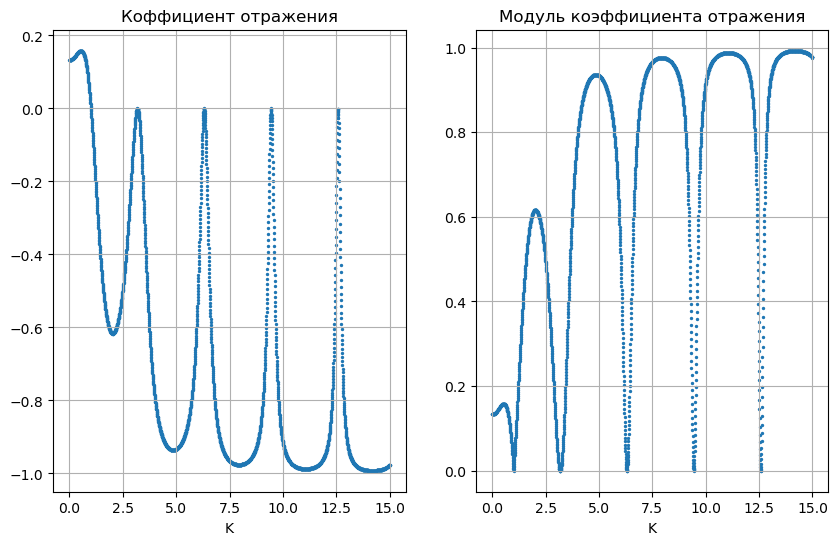

In [561]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 6))
ax1.scatter(k_real, np.real(r_vals), s=2)
ax1.set_title('Коффициент отражения')
ax1.set_xlabel('K')
ax1.grid()
ax2.scatter(k_real, np.abs(np.real(r_vals)), s=2)
ax2.set_title('Модуль коэффициента отражения')
ax2.set_xlabel('K')
ax2.grid()

In [562]:
epsilon = 1e-3
k_close = k_real[np.abs(r_vals) < epsilon]
print("Все k_real, для которых r_vals близки к нулю:", k_close)

Все k_real, для которых r_vals близки к нулю: [1.00033344 3.18106035 9.43814605]


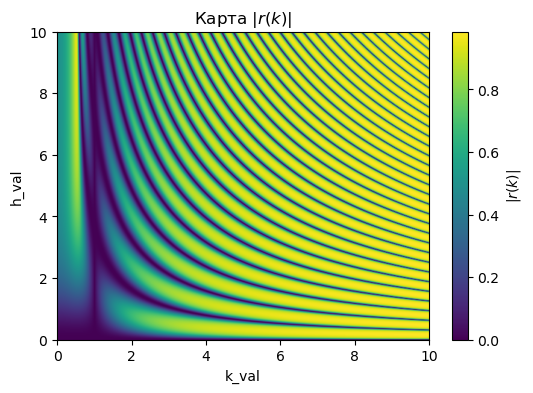

In [563]:
h_vals = np.linspace(0, 10, 500)
k_vals = np.linspace(0, 10, 500)
r_vals1 = []
for h in h_vals:
    r_vals1.append(r_total(k_vals, k0, k2, theta0, h))

plt.figure(figsize=(6, 4))
plt.imshow(
    np.abs(np.real(r_vals1)),
    origin="lower",
    extent=[k_vals.min(), k_vals.max(), h_vals.min(), h_vals.max()],
    aspect="auto"
)
plt.colorbar(label=r"$|r(k)|$")
plt.xlabel(r"k_val")
plt.ylabel(r"h_val")
plt.title(r"Карта $|r(k)|$")
plt.show()

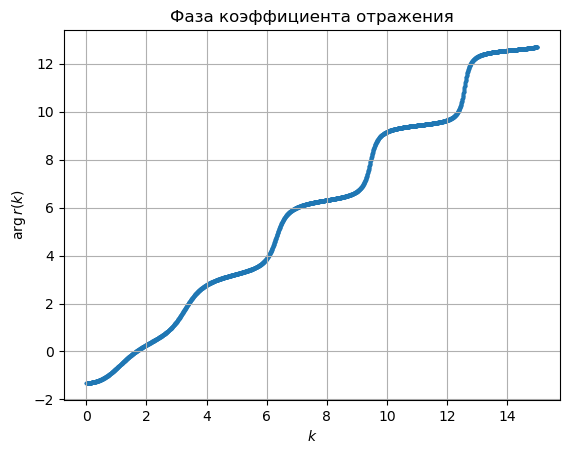

In [564]:
plt.figure()
plt.scatter(k_real, np.unwrap(np.angle(r_vals), period=np.pi), s=3)
plt.xlabel(r"$k$")
plt.ylabel(r"$\arg r(k)$")
plt.title("Фаза коэффициента отражения")
plt.grid()
plt.show()

In [565]:
print("Максимум |r| =", np.max(np.abs(r_vals)))

Максимум |r| = 0.9925599959051542


## Step 2

In [566]:
# Диапазоны
k_real = np.linspace(0.8 * k0, 6.0 * k0, 1000)
k_imag = np.linspace(0.0, 5.0, 300)
h = 1

K_real, K_imag = np.meshgrid(k_real, k_imag)
K = K_real + 1j * K_imag

In [567]:
R = r_total(K, k0, k2, theta0, h)

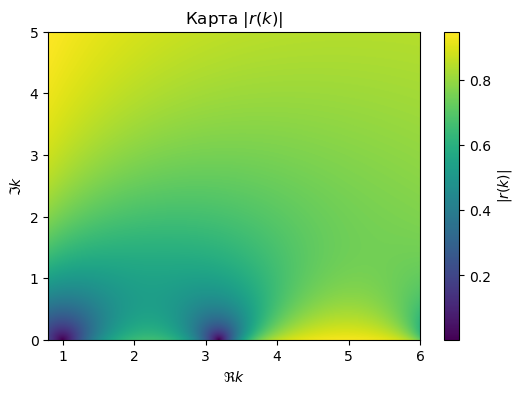

In [568]:
plt.figure(figsize=(6, 4))
plt.imshow(
    np.abs(R),
    origin="lower",
    extent=[k_real.min(), k_real.max(), k_imag.min(), k_imag.max()],
    aspect="auto"
)
plt.colorbar(label=r"$|r(k)|$")
plt.xlabel(r"$\Re k$")
plt.ylabel(r"$\Im k$")
plt.title(r"Карта $|r(k)|$")
plt.show()


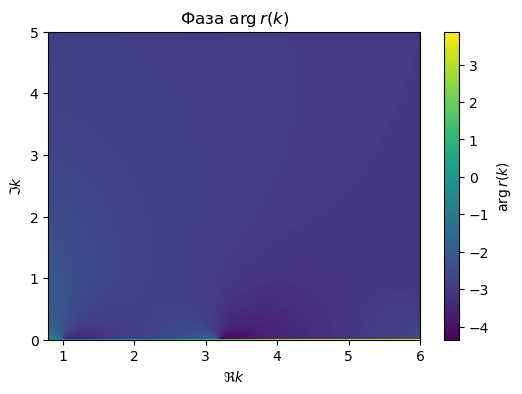

In [569]:
plt.figure(figsize=(6, 4))
plt.imshow(
    np.unwrap(np.angle(R), period=np.pi),
    origin="lower",
    extent=[k_real.min(), k_real.max(), k_imag.min(), k_imag.max()],
    aspect="auto",
    # cmap="twilight"
)
plt.colorbar(label=r"$\arg r(k)$")
plt.xlabel(r"$\Re k$")
plt.ylabel(r"$\Im k$")
plt.title(r"Фаза $\arg r(k)$")
plt.show()

## Step 3

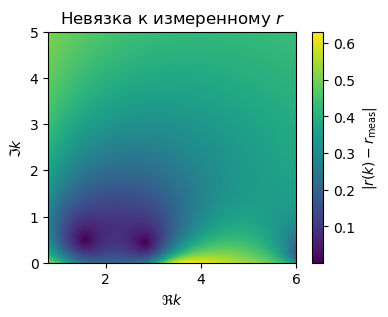

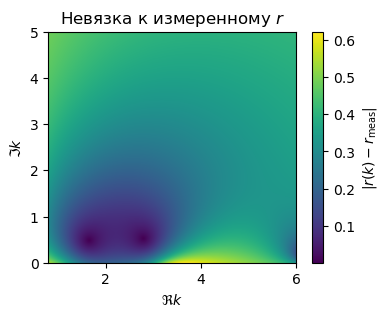

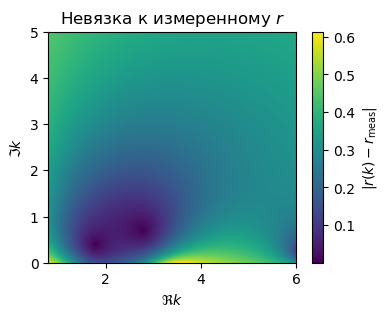

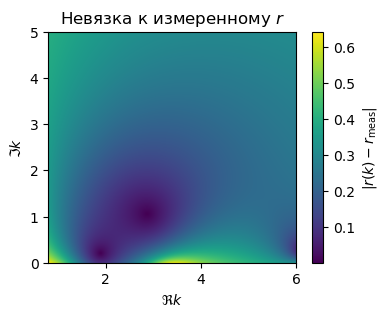

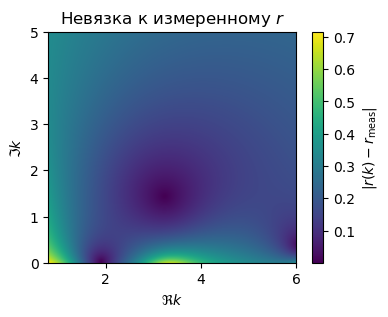

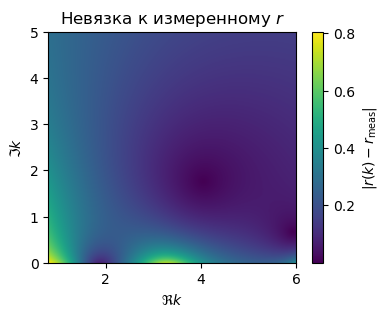

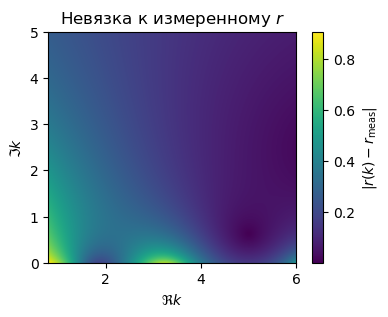

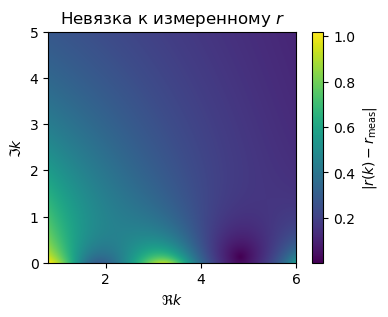

In [570]:
for theta in [np.deg2rad(i) for i in range(10, 90, 10)]:
    k_star = 1.8 * k0 + 0.4j
    r_star = r_total(k_star, k0, k2, theta, 1)
    residual = np.abs(R - r_star)

    plt.figure(figsize=(4, 3))
    plt.imshow(
        residual,
        origin="lower",
        extent=[k_real.min(), k_real.max(), k_imag.min(), k_imag.max()],
        aspect="auto"
    )
    plt.colorbar(label=r"$|r(k) - r_{\mathrm{meas}}|$")
    plt.xlabel(r"$\Re k$")
    plt.ylabel(r"$\Im k$")
    plt.title(r"Невязка к измеренному $r$")
    plt.show()


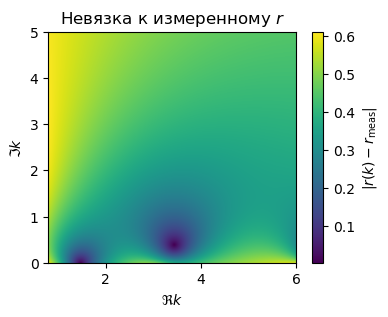

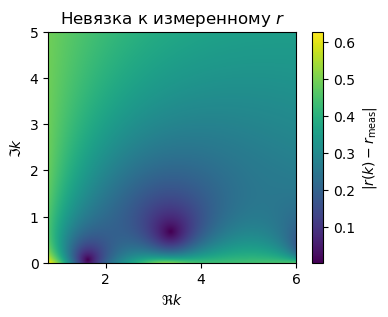

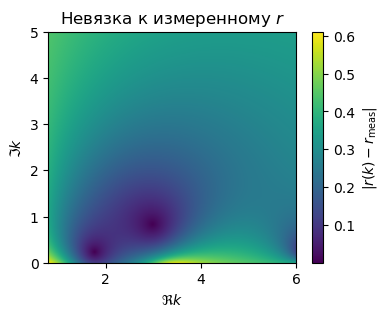

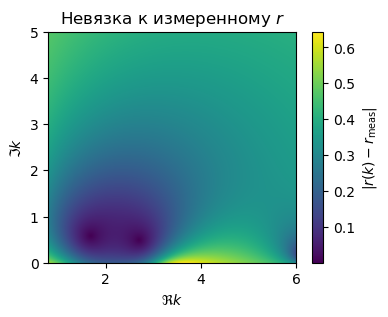

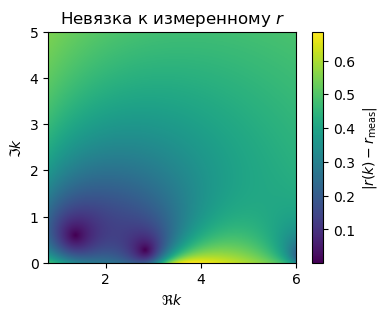

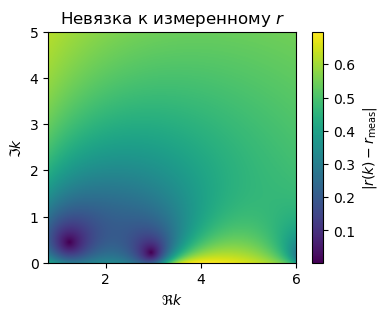

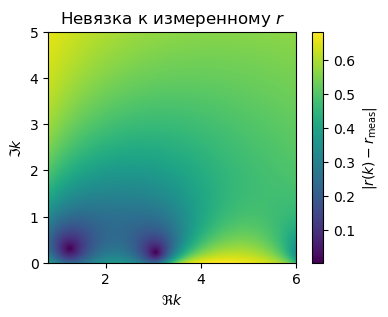

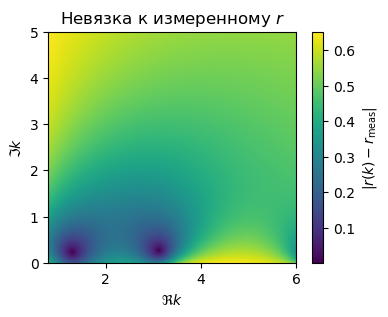

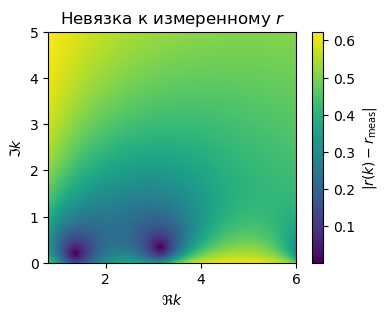

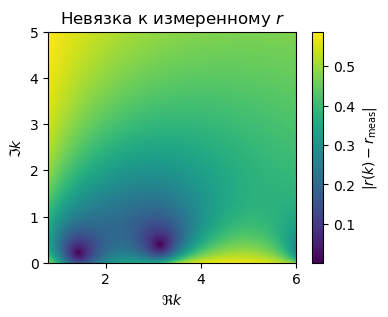

In [554]:
for h in [0.5+ 0.2*i for i in range(10)]:
    k_star = 1.8 * k0 + 0.4j
    r_star = r_total(k_star, k0, k2, theta0, h)
    residual = np.abs(R - r_star)

    plt.figure(figsize=(4, 3))
    plt.imshow(
        residual,
        origin="lower",
        extent=[k_real.min(), k_real.max(), k_imag.min(), k_imag.max()],
        aspect="auto"
    )
    plt.colorbar(label=r"$|r(k) - r_{\mathrm{meas}}|$")
    plt.xlabel(r"$\Re k$")
    plt.ylabel(r"$\Im k$")
    plt.title(r"Невязка к измеренному $r$")
    plt.show()


### Вывод

 - Обратная задача восстановления комплексного волнового числа слоя по одному коэффициенту отражения неединственна. Невязка имеет вытянутые минимумы в пространстве параметров. 

 - Увеличение толщины слоя повышает чувствительность к действительной части волнового числа за счет фазовой интерференции, в то время как изменение угла падения в первую очередь влияет на мнимую часть за счет изменения продольной компоненты волнового ыектора.

## Step 4

In [555]:
k0 = 1
k2 = 1
h = 1
theta0 = np.deg2rad(30)

k_real = np.linspace(0.8 * k0, 6.0 * k0, 1000)
k_imag = np.linspace(0.0, 0.0, 300)

K_real, K_imag = np.meshgrid(k_real, k_imag)
K = K_real + 1j * K_imag

k_star = 1.8*k0 + 0.4j

R = r_total(K, k0, k2, theta0, h)
r_meas = r_total(k_star, k0, k2, theta0, h)
misfit = np.abs(R - r_meas)

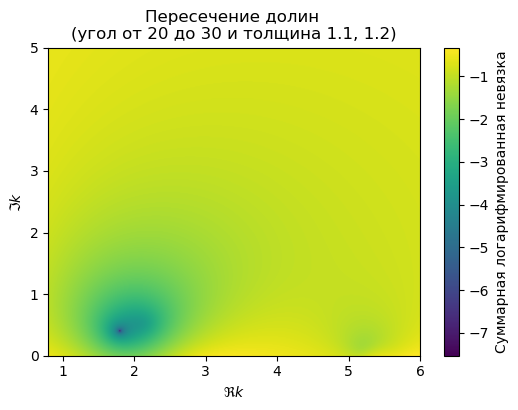

In [571]:
total_misfit = 0
count = 0

for si in range(20, 30, 2):
    for hi in range(1, 3):
        Ri = r_total(K, k0, k2, np.deg2rad(si), 1+hi*0.1)
        ri_meas = r_total(k_star, k0, k2, np.deg2rad(si), 1+hi*0.1)
        misfit_i = np.abs(Ri - ri_meas)**2

        total_misfit += misfit_i
        count += 1

total_misfit /= count

plt.figure(figsize=(6, 4))
plt.imshow(
    np.log10(total_misfit),
    origin="lower",
    extent=[k_real.min(), k_real.max(), k_imag.min(), k_imag.max()],
    aspect="auto"
)
plt.colorbar(label="Суммарная логарифмированная невязка")
plt.xlabel(r"$\Re k$")
plt.ylabel(r"$\Im k$")
plt.title("Пересечение долин \n(угол от 20 до 30 и толщина 1.1, 1.2)")
plt.show()


In [572]:
idx = np.unravel_index(np.argmin(total_misfit), total_misfit.shape)
print(K[idx])

(1.7993993993993995+0.4013377926421404j)


### Вывод
 - При наличии набора углов и толщин функционал невязки имеет единственную устойчивую область минимума в пространстве комплексного волнового числа.
  - Использование квадратичного функционала невязки приводит к расширению области визуального минимума вследствие слабой чувствительности нормы второго порядка вблизи нуля. Однако логарифмическое масштабирование выявляет локальную структуру минимума, которая остаётся устойчиво локализованной в окрестности истинного параметра.